# Sensor Air Quality Index (AQI) calculation for the past 1h, 8h or 24h

#### Before starting run the next cell to install the required Python libraries first required to run the code:

In [ ]:
# run this cell once only if you need to install the libraries
!pip install requests pandas plotly matplotlib seaborn
!pip install --upgrade pip

### **Step 1: Get Sensor Data: Request your sensor device last observations from the database (API).**
#### You need to run the next cell and you will be asked to:
- Enter Smart Citizen device ID:
- Select the time to use to calculate the AQI: "1 - last 1 hour"; "2 - last 8 hours";  "3 - last 24 hours"
- Select the Observed Property: "1 - Particle Matter PM 2.5"; "2 - Carbon Dioxide"

Enter your Smart Citizen Device ID:  17277



Select the time range to retrieve data:
1 - Last 1 hour
2 - Last 8 hours
3 - Last 24 hours


Enter 1, 2, or 3:  2



Select the observed property:
1 - PM 2.5 (Particulate Matter)
2 - CO₂ (Carbon Dioxide)


Enter 1 or 2:  1



Fetching data from: https://api.smartcitizen.me/v0/devices/17277/readings?sensor_id=87&rollup=5m&from=2025-06-25T06:46:06&to=2025-06-25T14:46:06


,datetime,value
0,2025-06-25 14:40:12+00:00,2
1,2025-06-25 14:29:11+00:00,2
2,2025-06-25 14:23:43+00:00,1
3,2025-06-25 14:18:14+00:00,1
4,2025-06-25 14:12:19+00:00,1
5,2025-06-25 14:07:04+00:00,2
6,2025-06-25 14:01:16+00:00,1
7,2025-06-25 13:51:05+00:00,0
8,2025-06-25 13:46:03+00:00,1
9,2025-06-25 13:40:38+00:00,1


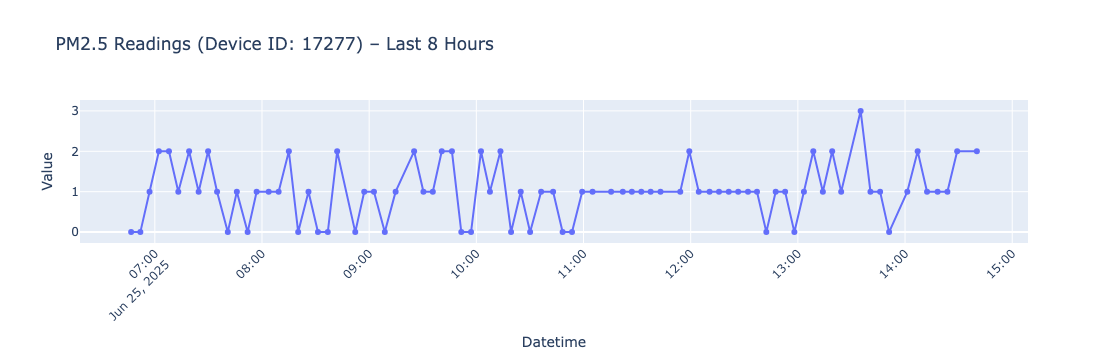

In [3]:
# Run this cell to be asked for your input below
import requests
import datetime
import pandas as pd
import plotly.express as px
import seaborn as sns
from IPython.display import display, HTML

def get_sensor_data():
    try:
        # 1. Device ID input
        device_id = input("Enter your Smart Citizen Device ID: ").strip()
        # 17277 - Blackrock, Dublin, Ireland
        # 17183 - Dalkey, Ireland
        if not device_id:
            raise ValueError("Device ID cannot be empty.")
        
        # 2. Time range selection
        print("\nSelect the time range to retrieve data:")
        print("1 - Last 1 hour")
        print("2 - Last 8 hours")
        print("3 - Last 24 hours")
        time_choice = input("Enter 1, 2, or 3: ").strip()
        
        time_mapping = {"1": 1, "2": 8, "3": 24}
        hours_back = time_mapping.get(time_choice)
        if not hours_back:
            raise ValueError("Invalid choice for time range. Please enter 1, 2, or 3.")
        
        # 3. Observed property selection
        print("\nSelect the observed property:")
        print("1 - PM 2.5 (Particulate Matter)")
        print("2 - CO₂ (Carbon Dioxide)")
        sensor_choice = input("Enter 1 or 2: ").strip()
        
        sensor_mapping = {
            "1": 87,  # PM2.5 on SmartCitizen platform
            "2": 112  # CO2 (eCO2) on SmartCitizen platform
        }
        observed_property_mapping = {"1": "PM2.5", "2": "CO2"}
        sensor_id = sensor_mapping.get(sensor_choice)
        observed_property_name = observed_property_mapping.get(sensor_choice)
        if not sensor_id or not observed_property_name:
            raise ValueError("Invalid choice for observed property. Please enter 1 or 2.")
        
        # 4. Define time window
        now = datetime.datetime.utcnow()
        from_time = now - datetime.timedelta(hours=hours_back)
        from_time_str = from_time.strftime('%Y-%m-%dT%H:%M:%S')
        to_time_str = now.strftime('%Y-%m-%dT%H:%M:%S')
        time_interval_str = f"{hours_back}h"

        # 5. Fetch data from API
        api_url = (
            f"https://api.smartcitizen.me/v0/devices/{device_id}/readings?"
            f"sensor_id={sensor_id}&rollup=5m&from={from_time_str}&to={to_time_str}"
        )
        print(f"\nFetching data from: {api_url}")
        response = requests.get(api_url)
        response.raise_for_status()
        data = response.json()
        
        # 6. Parse readings
        observations = data.get("readings", [])
        if not observations:
            raise ValueError("No observations found for the selected parameters.")
        
        df = pd.DataFrame(observations, columns=["datetime", "value"])
        df["datetime"] = pd.to_datetime(df["datetime"])
        observations_avg = df["value"].mean()

        # 7. Display table
        sns.set_style("whitegrid")
        display(HTML(f"""
        <style>
            .table-container {{
                width: 100%;
                display: flex;
                justify-content: center;
            }}
            .table-striped {{
                width: 100%;
                max-width: 100%;
            }}
        </style>
        <div class='table-container'>
            {df.to_html(classes='table table-striped', escape=False, border=0)}
        </div>
        """))

        # 8. Plot chart
        # 8. Plot chart
        fig = px.line(df, x='datetime', y='value',
                      title=f"{observed_property_name} Readings (Device ID: {device_id}) – Last {hours_back} Hours",
                      markers=True)
        fig.update_xaxes(title_text='Datetime', tickangle=-45)
        fig.update_yaxes(title_text='Value')
        fig.show()

        # 9. Display average
        display(HTML(
            f"<h3>Average {observed_property_name} value over the last {time_interval_str}: "
            f"<strong>{observations_avg:.2f}</strong></h3>"
        ))

        return df, observed_property_name, observations_avg, time_interval_str, from_time_str, to_time_str

    except requests.exceptions.RequestException as e:
        print(f"\nNetwork error: {e}")
    except ValueError as e:
        print(f"\nInput error: {e}")
    except Exception as e:
        print(f"\nUnexpected error: {e}")

    return None, None, None, None, None, None

# Run the function
readings_df, observed_property_name, observations_avg, time_interval_str, from_time_str, to_time_str = get_sensor_data()

### **Step 2: Air Quality Index calculation using the sensor observations retrieved before.**
#### You need to run the next cell, you will be asked to:
- Select the guideline you want to use for the AQI standard: "1 - US EPA"; "2 - TwinAIR project AQI"

In [4]:
# Using remote API to compute AQI
import logging
from urllib.parse import urlencode
import pandas as pd
import requests
from IPython.display import HTML, display

logger = logging.getLogger("notebook.aqi")

# -------------------------------------------------------------------- helpers
API_BASE = (
    "https://environmental-data.spatialdynamics.cloud"
    "/api/v1/processes/aqi-calc/"
)

# Map our sensor labels → query-string expected by the API
POLLUTANT_QS = {
    "PM2.5": "pm25",
    "CO2": "co2",          # eCO2 from Smart-Citizen
}

def _call_aqi_service(pollutant: str, value: float, guideline: str) -> dict:
    qs_params = {
        "pollutant": POLLUTANT_QS.get(pollutant, pollutant.lower()),
        "observation": value,
        "guideline": guideline,
    }
    url = f"{API_BASE}?{urlencode(qs_params)}"
    logger.debug("Calling AQI service → %s", url)

    resp = requests.get(url, timeout=10)
    resp.raise_for_status()
    return resp.json()

# -------------------------------------------------------------------- user input (guideline)
print("\nSelect the AQI guideline:")
print("1 – USEPA")
print("2 – TwinAIR Project (default)")
guideline = {"1": "USEPA", "2": "TwinAIR"}.get(input("Choice: ").strip(), "TwinAIR")

# -------------------------------------------------------------------- guard
if not all(
    var is not None
    for var in (
        observed_property_name,
        observations_avg,
        time_interval_str,
        from_time_str,
        to_time_str,
    )
):
    print("⚠️  Please run Cell 1 first so we have the sensor data.")
else:
    # ---------------------------------------------------------------- call API
    try:
        aqi = _call_aqi_service(
            pollutant=observed_property_name,
            value=round(float(observations_avg), 2),
            guideline=guideline,
        )
    except requests.HTTPError as e:
        print(f"API error: {e} – {e.response.text}")
    except Exception as e:
        print(f"Unexpected error contacting AQI service: {e}")
    else:
        # ---------------------------------------------------------------- table
        df_res = pd.DataFrame.from_records(
            [
                {
                    "Pollutant": aqi["pollutant"],
                    "Input Value": round(float(aqi["observation_input"]), 2),
                    "Total observations": len(readings_df)
                    if "readings_df" in globals() and readings_df is not None
                    else "n/a",
                    "AQI Index": aqi["aqi_index"],
                    "Band": aqi["index"],
                    "Rating": aqi["rating"],
                    "Time Interval": time_interval_str,
                    "Guideline": aqi["guideline"],
                    "Start": from_time_str,
                    "End": to_time_str,
                }
            ]
        )

        # Style – one background colour for the whole row
        styled = (
            df_res.style.format({"Input Value": "{:.2f}", "AQI Index": "{:.1f}"})
            .map(lambda _: f"background-color:{aqi['rating_color']};color:black")
        )

        display(HTML(styled.to_html()))


Select the AQI guideline:
1 – USEPA
2 – TwinAIR Project (default)


Choice:  1


,Pollutant,Input Value,Total observations,AQI Index,Band,Rating,Time Interval,Guideline,Start,End
0,PM2.5,1.01,81,5.0,1,Excellent,8h,USEPA,2025-06-25T06:46:06,2025-06-25T14:46:06
